In [141]:
everything = {}

In [142]:
import os 
import pickle
from vertex_voyage.temporal_partitioning import PartitionerProfile
import numpy as np
cwd = os.getcwd()
from vertex_voyage.partitioning import get_partition_average_balance


def compute_run_stats(runs, f1s):
    """Aggregate a list of raw profile runs + a list of raw iteration_f1s arrays
    into the same summary dict shape stored in `everything`, exactly like a
    single directory walk would produce."""
    average_edge_cuts = np.mean([run['edge_cuts_percentage'] for run in runs], axis=0)
    average_repartitionings = np.mean([run['repartitionings'] for run in runs], axis=0)
    average_repartitioning_percentages = np.mean([run['repartitioning percentage'] for run in runs], axis=0)
    average_balance = np.mean([run['balance'] for run in runs], axis=0)
    average_f1s = np.mean([f1 for f1 in f1s], axis=0) if f1s else None
    stddev_f1s = np.std([f1 for f1 in f1s], axis=0) if f1s else None
    return {
        "average_edge_cuts": average_edge_cuts,
        "average_repartitionings": average_repartitionings,
        "average_f1s": average_f1s,
        "stddev_f1s": stddev_f1s,
        "average_repartitioning_percentages": average_repartitioning_percentages,
        "average_balance": average_balance,
        "runs": runs,
        "f1s": f1s,
        "f1": average_f1s[-1] if average_f1s is not None else 0,
    }


def merge_everything(dict_a, dict_b):
    """Merge two `everything`-shaped dicts (same key = (dataset, partitions, RF))
    that came from different root directories (e.g. temporal_runs/A and
    temporal_runs/_1/A) into one, as if all their underlying runs and F1
    iterations had been collected in a single pass.

    For keys present in only one of the dicts, that entry is kept as-is.
    For keys present in both, the raw `runs` and `f1s` lists are concatenated
    and every aggregate statistic (average edge cuts, repartitionings,
    balance, F1 mean/stddev, ...) is recomputed from the combined raw data.
    """
    merged = {}
    for key in set(dict_a.keys()) | set(dict_b.keys()):
        entry_a = dict_a.get(key)
        entry_b = dict_b.get(key)
        if entry_a is not None and entry_b is not None:
            combined_runs = entry_a["runs"] + entry_b["runs"]
            combined_f1s = entry_a.get("f1s", []) + entry_b.get("f1s", [])
            merged[key] = compute_run_stats(combined_runs, combined_f1s)
        else:
            merged[key] = entry_a if entry_a is not None else entry_b
    return merged


def add_to_everything(suffix, param_type: type = int):
    global everything
    runs_folder = os.path.join(cwd, "..", "temporal_runs", suffix)
    display(f"Searching for profile files in: {runs_folder}")
    for root, dirs, files in os.walk(runs_folder):
        name = os.path.basename(root)
        # name should be in the format "datasetname-partitions_RF"
        name = name.split("-")
        if len(name) < 2:
            # display(f"Skipping {root} as it does not match the expected format.")
            continue
        if len(name[-1].split("_")) < 2:
            # display(f"Skipping {root} as it does not match the expected format.")
            continue
        dataset_name = "-".join(name[:-1])
        parts = name[-1].split("_")[0]
        rf = name[-1].split("_")[1]
        key = (dataset_name, int(parts), param_type(rf))
        runs = []
        f1s = [] 
        for file in files:
            if file.startswith("profile"):
                file_path = os.path.join(root, file)
                with open(file_path, "rb") as f:
                    run = pickle.load(f)
                    try:
                        if param_type != int:
                            total_vertices = [sum(x  for x in k.values()) for k in run['partition_sizes']]
                        else:
                            total_vertices = [sum(x // (int(rf)) for x in k.values()) for k in run['partition_sizes']]
                    except ValueError:
                        total_vertices = [sum(x for x in k.values()) for k in run['partition_sizes']]
                    balance = [get_partition_average_balance(k, len(k.keys())) for k in run['partition_sizes']]
                    run['balance'] = balance
                    run['total_vertices'] = total_vertices
                    run["repartitioning percentage"] = [r / v if v > 0 else 0 for r, v in zip(run['repartitionings'], total_vertices)]
                    if isinstance(run, dict):
                        runs.append(run)
                    else:
                        print(f"File {file_path} is not a PartitionerProfile instance.")
            if file.startswith("iteration_f1s"):
                file_path = os.path.join(root, file)
                with open(file_path, "rb") as f:
                    f1s.append(pickle.load(f))
        if runs:
            stats = compute_run_stats(runs, f1s)
            # display(f"Found {len(runs)} profile files in {root}")
            # display(os.path.basename(root))
            # display(f"Average edge cuts: {stats['average_edge_cuts']}")
            # display(f"Average repartitionings: {stats['average_repartitionings']}")
            # display(f"Average F1 scores: {stats['average_f1s']}")
            # display(f"Stddev F1 scores: {stats['stddev_f1s']}")
            # display(f"Average repartitioning percentages: {stats['average_repartitioning_percentages']}")
            display(f"{dataset_name}: Average F1 score at last iteration: {stats['f1']}")
            # for run in runs:
                # display(run)
            if key in everything:
                everything[key] = merge_everything({key: everything[key]}, {key: stats})[key]
            else:
                everything[key] = stats
# add_to_everything("hetzner")
# add_to_everything("ai_cluster")
add_to_everything("macbook")
add_to_everything("macbook_new")
all_datasets = set(key[0] for key in everything.keys())
all_partitions = set(key[1] for key in everything.keys())
all_rfs = set(key[2] for key in everything.keys())


'Searching for profile files in: /Users/stefan/data/Development/VertexVoyage/notebooks/../temporal_runs/macbook'

'DBLP: Average F1 score at last iteration: 0.5434618159411816'

'DBLP: Average F1 score at last iteration: 0.5006599762355777'

'AS-Oregon: Average F1 score at last iteration: 0.26583301672420817'

'AstroPh: Average F1 score at last iteration: 0.46820128996466837'

...

'CITESEER: Average F1 score at last iteration: 0.5534927193697954'

'CITESEER: Average F1 score at last iteration: 0.4584170702990728'

'AS-Oregon: Average F1 score at last iteration: 0.23611411339128263'

'CITESEER: Average F1 score at last iteration: 0.5531003372833385'

'CITESEER: Average F1 score at last iteration: 0.5928617513876462'

In [143]:
import matplotlib.pyplot as plt
import pandas as pd

for dataset in all_datasets:
    print(f"Dataset: {dataset}")
    data = [] 
    for partitions in all_partitions:
        for rf in [1]:
            key = (dataset, partitions, rf)
            if key in everything:
                f1s = everything[key]["average_f1s"]
                f1s_stddev = everything[key]["stddev_f1s"]
                # print("f1s: ", f1s)
                # plt.plot(f1s, label=f"P={partitions}")
                partition_sizes = everything[key]["runs"][0]["partition_sizes"] if everything[key]["runs"] else None
                repartitionings = everything[key]["average_repartitionings"] if everything[key]["average_repartitionings"] is not None else None
                repartitioning_percentages = everything[key]["average_repartitioning_percentages"] if everything[key]["average_repartitioning_percentages"] is not None else None
                edge_cuts = everything[key]["average_edge_cuts"] if everything[key]["average_edge_cuts"] is not None else None
                balance = everything[key]["average_balance"][-1] if everything[key]["average_balance"] is not None else None
                data.append({
                    "# of partitions": partitions,
                    "F1 reconstruction score": f1s[-1] if f1s is not None else 0,
                    "F1 reconstruction score stddev": f1s_stddev[-1] if f1s_stddev is not None else 0,
                    "% of edge cuts": everything[key]["average_edge_cuts"][-1] if everything[key]["average_edge_cuts"] is not None else 0,
                    "Balance": balance if balance is not None else 0,
                })
    data = sorted(data, key=lambda x: x["# of partitions"])
    df = pd.DataFrame(data)
    display(df)
    # plt.xlabel("Iteration")
    # plt.ylabel("Average F1 Score")
    # plt.title(f"Average F1 Scores for Dataset {dataset}")
    # plt.legend()
    # plt.show()

Dataset: AS-Oregon


,# of partitions,F1 reconstruction score,F1 reconstruction score stddev,% of edge cuts,Balance
0,1,0.261739,0.005747,0.000000,1.000000
1,2,0.248825,0.027154,0.377865,1.127901
2,4,0.242965,0.009821,0.567537,1.204246
3,8,0.214547,0.011886,0.695753,1.365083


Dataset: AstroPh


,# of partitions,F1 reconstruction score,F1 reconstruction score stddev,% of edge cuts,Balance
0,1,0.576977,0.001050,0.000000,1.000000
1,2,0.546667,0.003596,0.350962,1.078042
2,4,0.509502,0.004507,0.558864,1.111762
3,8,0.459426,0.005090,0.654033,1.257631


Dataset: Enron


,# of partitions,F1 reconstruction score,F1 reconstruction score stddev,% of edge cuts,Balance
0,1,0.176319,0.0,0.000000,1.000000
1,2,0.243491,0.0,0.330739,1.091955
2,4,0.314363,0.0,0.491778,1.081162
3,8,0.306829,0.0,0.619917,1.250000


Dataset: DBLP


,# of partitions,F1 reconstruction score,F1 reconstruction score stddev,% of edge cuts,Balance
0,1,0.509100,0.003131,0.000000,1.000000
1,2,0.541110,0.001837,0.324796,1.103861
2,4,0.545086,0.001519,0.500482,1.195755
3,8,0.498667,0.001572,0.590581,1.306206


Dataset: CITESEER


,# of partitions,F1 reconstruction score,F1 reconstruction score stddev,% of edge cuts,Balance
0,1,0.475684,0.015638,0.000000,1.000000
1,2,0.458063,0.005947,0.230379,1.308211
2,4,0.480598,0.005259,0.387125,1.628064
3,8,0.548150,0.016565,0.480820,1.750000


In [144]:
import numpy as np
import pandas as pd
from scipy import stats


def get_last_iter_f1s(dataset, partitions, rf=1):
    """Raw last-iteration F1 score for every individual run of a (dataset, partitions, rf) config."""
    key = (dataset, partitions, rf)
    if key not in everything:
        return None
    f1s_list = everything[key].get("f1s", [])
    vals = np.array([run[-1] for run in f1s_list if len(run) > 0])
    return vals if len(vals) > 0 else None


def significance_summary_table(dataset, partitions_sorted, rf=1):
    rows = []
    for p in partitions_sorted:
        vals = get_last_iter_f1s(dataset, p, rf)
        if vals is None:
            continue
        rows.append({
            "# of partitions": p,
            "n runs": len(vals),
            "Mean F1": f"{vals.mean() * 100:.2f}%",
            "Std F1": f"{vals.std(ddof=0) * 100:.2f}%",
        })
    return pd.DataFrame(rows)


def significance_pairs_table(dataset, pairs, rf=1):
    rows = []
    for a, b in pairs:
        vals_a = get_last_iter_f1s(dataset, a, rf)
        vals_b = get_last_iter_f1s(dataset, b, rf)
        if vals_a is None or vals_b is None or len(vals_a) < 2 or len(vals_b) < 2:
            continue
        t_stat, p_t = stats.ttest_ind(vals_a, vals_b, equal_var=False)
        u_stat, p_u = stats.mannwhitneyu(vals_a, vals_b, alternative="two-sided")
        pooled_std = np.sqrt((vals_a.std(ddof=1) ** 2 + vals_b.std(ddof=1) ** 2) / 2)
        cohens_d = (vals_b.mean() - vals_a.mean()) / pooled_std if pooled_std > 0 else np.nan
        rows.append({
            "Comparison": f"P={a} vs P={b}",
            "Welch t-test p": round(p_t, 4),
            "Mann-Whitney p": round(p_u, 4),
            "Cohen's d": round(cohens_d, 2),
            "Significant (α=0.05)": "Yes" if p_t < 0.05 else "No",
        })
    return pd.DataFrame(rows)


def report_significance(dataset, rf=1):
    """Print per-partition F1 stats plus pairwise significance tests (Welch t-test +
    Mann-Whitney U on the raw per-run last-iteration F1 scores) against the baseline
    partition count and between adjacent partition counts."""
    partitions_sorted = sorted(p for p in all_partitions if (dataset, p, rf) in everything)
    if len(partitions_sorted) < 2:
        return
    display(f"{dataset}: F1 significance across partition counts (RF={rf})")
    display(significance_summary_table(dataset, partitions_sorted, rf))

    baseline = partitions_sorted[0]
    baseline_pairs_df = significance_pairs_table(dataset, [(baseline, p) for p in partitions_sorted[1:]], rf)
    if baseline_pairs_df.empty:
        display(f"Not enough runs per config to test significance (need ≥2 runs each).")
    else:
        display(f"vs. baseline (P={baseline}):")
        display(baseline_pairs_df)
        display("Adjacent partition counts:")
        display(significance_pairs_table(dataset, list(zip(partitions_sorted, partitions_sorted[1:])), rf))


for dataset in sorted(all_datasets):
    report_significance(dataset)


'AS-Oregon: F1 significance across partition counts (RF=1)'

,# of partitions,n runs,Mean F1,Std F1
0,1,4,26.17%,0.57%
1,2,3,24.88%,2.72%
2,4,3,24.30%,0.98%
3,8,3,21.45%,1.19%


'vs. baseline (P=1):'

,Comparison,Welch t-test p,Mann-Whitney p,Cohen's d,Significant (α=0.05)
0,P=1 vs P=2,0.5723,0.6286,-0.54,No
1,P=1 vs P=4,0.0950,0.1143,-1.93,No
2,P=1 vs P=8,0.0188,0.0571,-4.17,Yes


'Adjacent partition counts:'

...

'Adjacent partition counts:'

,Comparison,Welch t-test p,Mann-Whitney p,Cohen's d,Significant (α=0.05)
0,P=1 vs P=2,0.0000,0.0286,10.80,Yes
1,P=2 vs P=4,0.0289,0.0571,2.04,Yes
2,P=4 vs P=8,0.0000,0.0286,-26.00,Yes


'Enron: F1 significance across partition counts (RF=1)'

,# of partitions,n runs,Mean F1,Std F1
0,1,1,17.63%,0.00%
1,2,1,24.35%,0.00%
2,4,1,31.44%,0.00%
3,8,1,30.68%,0.00%


'Not enough runs per config to test significance (need ≥2 runs each).'

Dataset: AS-Oregon


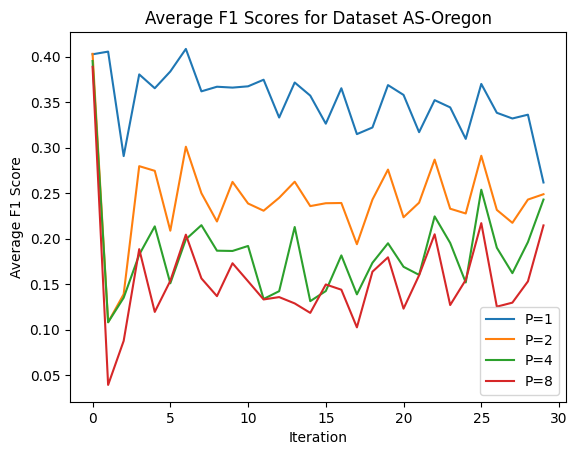

Dataset: AstroPh


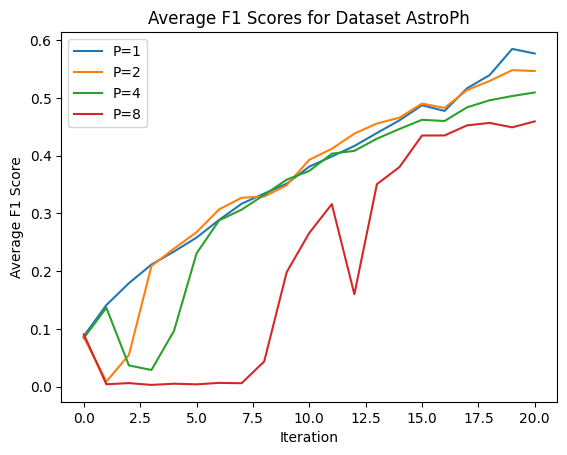

Dataset: Enron


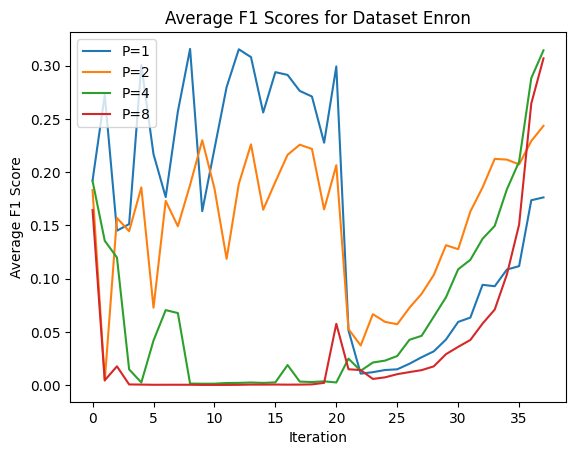

Dataset: DBLP


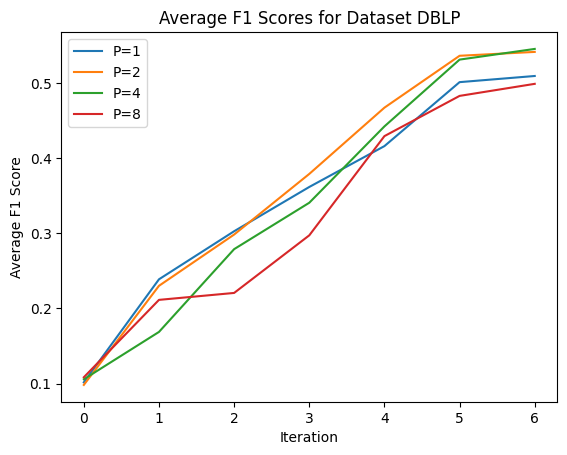

Dataset: CITESEER


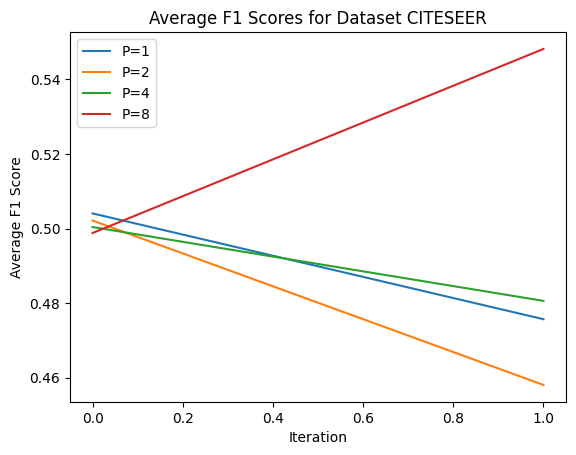

In [145]:
import matplotlib.pyplot as plt
import pandas as pd

for dataset in all_datasets:
    print(f"Dataset: {dataset}")
    data = []
    for partitions in sorted(all_partitions):
        for rf in [1]:
            key = (dataset, partitions, rf)
            if key in everything:
                f1s = everything[key]["average_f1s"]
                # print("f1s: ", f1s)
                # plt.plot(f1s, label=f"P={partitions}")
                partition_sizes = everything[key]["runs"][0]["partition_sizes"] if everything[key]["runs"] else None
                repartitionings = everything[key]["average_repartitionings"] if everything[key]["average_repartitionings"] is not None else None
                repartitioning_percentages = everything[key]["average_repartitioning_percentages"] if everything[key]["average_repartitioning_percentages"] is not None else None
                edge_cuts = everything[key]["average_edge_cuts"] if everything[key]["average_edge_cuts"] is not None else None
                balance = everything[key]["average_balance"] if everything[key]["average_balance"] is not None else None
                plt.plot(f1s, label=f"P={partitions}")
    plt.xlabel("Iteration")
    plt.ylabel("Average F1 Score")
    plt.title(f"Average F1 Scores for Dataset {dataset}")
    plt.legend()
    plt.show()

Dataset: AS-Oregon


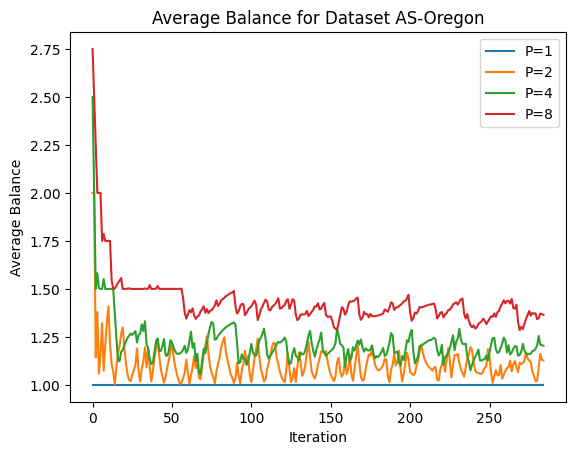

Dataset: AstroPh


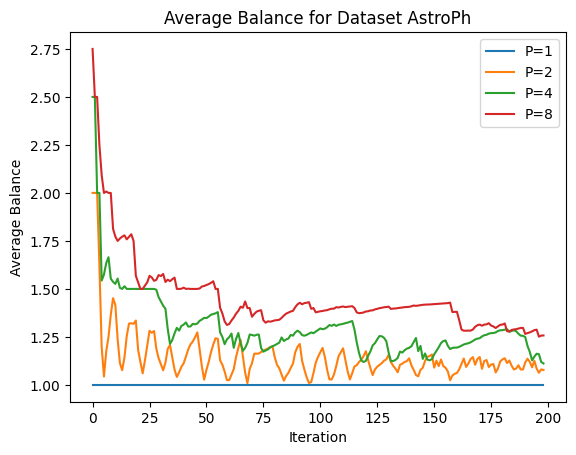

Dataset: Enron


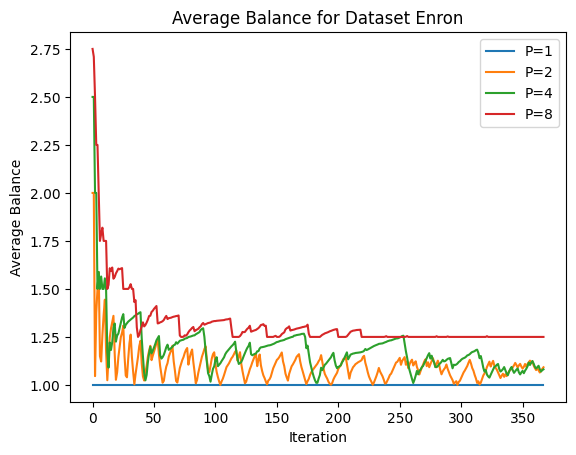

Dataset: DBLP


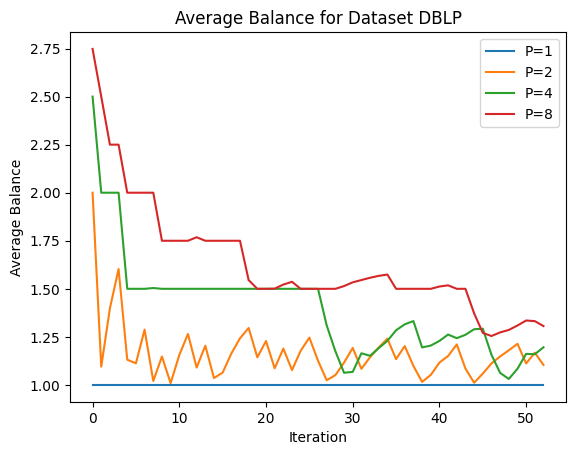

Dataset: CITESEER


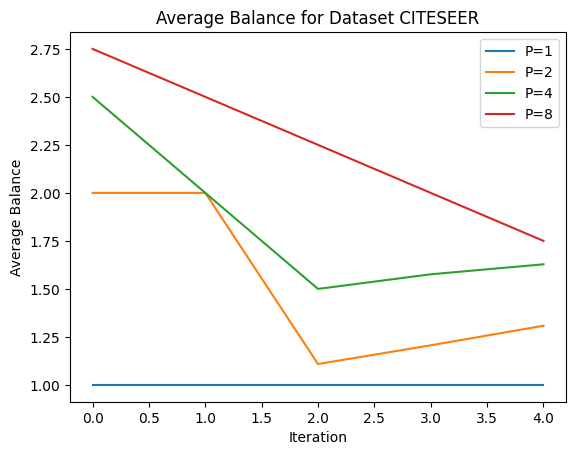

In [146]:
import matplotlib.pyplot as plt
import pandas as pd

for dataset in all_datasets:
    print(f"Dataset: {dataset}")
    data = []
    for partitions in sorted(all_partitions):
        for rf in [1]:
            key = (dataset, partitions, rf)
            if key in everything:
                f1s = everything[key]["average_f1s"]
                # print("f1s: ", f1s)
                # plt.plot(f1s, label=f"P={partitions}")
                partition_sizes = everything[key]["runs"][0]["partition_sizes"] if everything[key]["runs"] else None
                repartitionings = everything[key]["average_repartitionings"] if everything[key]["average_repartitionings"] is not None else None
                repartitioning_percentages = everything[key]["average_repartitioning_percentages"] if everything[key]["average_repartitioning_percentages"] is not None else None
                edge_cuts = everything[key]["average_edge_cuts"] if everything[key]["average_edge_cuts"] is not None else None
                balance = everything[key]["average_balance"] if everything[key]["average_balance"] is not None else None
                plt.plot(balance, label=f"P={partitions}")
    plt.xlabel("Iteration")
    plt.ylabel("Average Balance")
    plt.title(f"Average Balance for Dataset {dataset}")
    plt.legend()
    plt.show()

Dataset: AS-Oregon


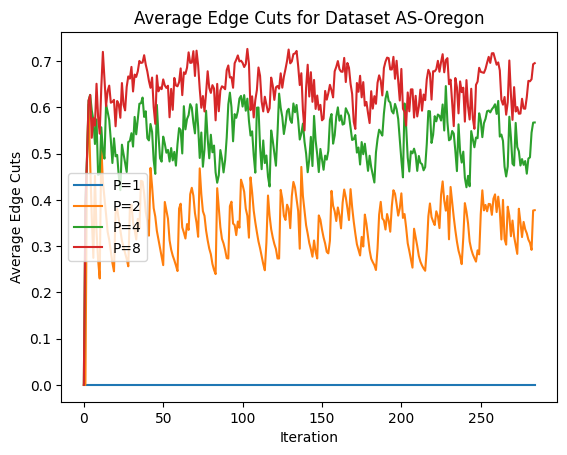

Dataset: AstroPh


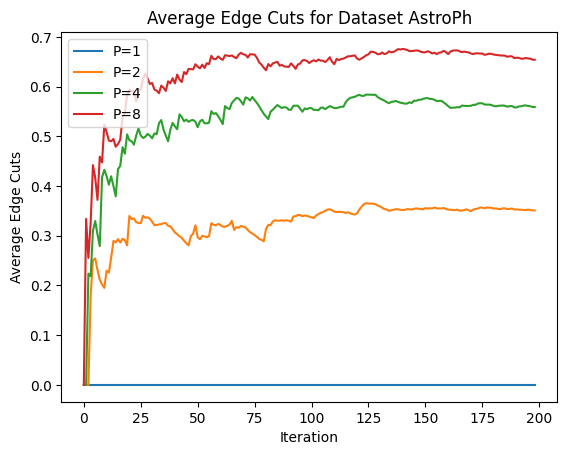

Dataset: Enron


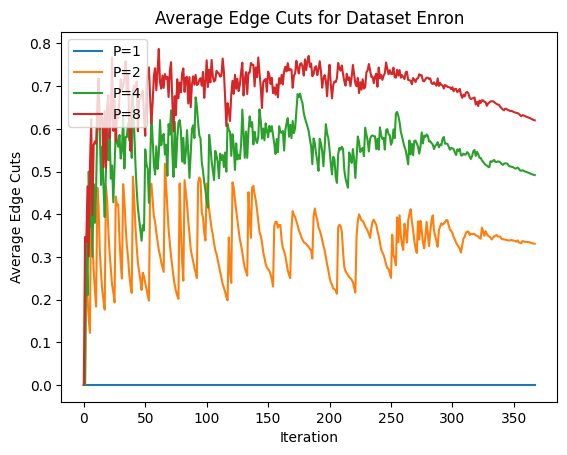

Dataset: DBLP


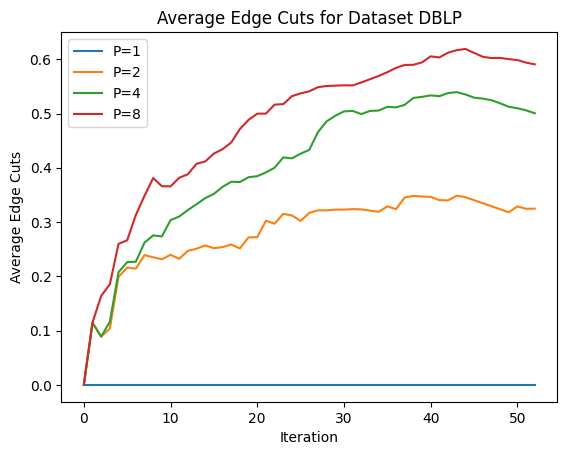

Dataset: CITESEER


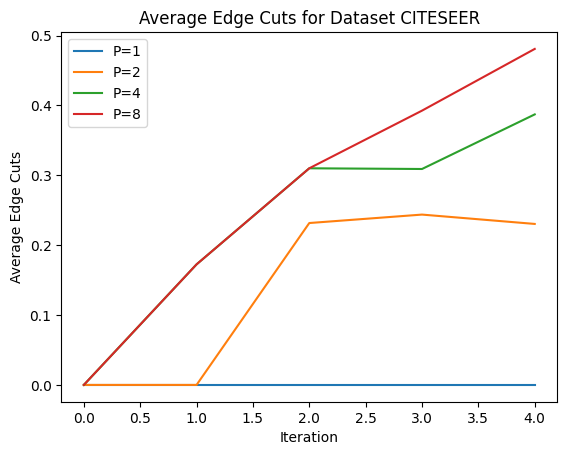

In [147]:
import matplotlib.pyplot as plt
import pandas as pd

for dataset in all_datasets:
    print(f"Dataset: {dataset}")
    data = []
    for partitions in sorted(all_partitions):
        for rf in [1]:
            key = (dataset, partitions, rf)
            if key in everything:
                f1s = everything[key]["average_f1s"]
                # print("f1s: ", f1s)
                # plt.plot(f1s, label=f"P={partitions}")
                partition_sizes = everything[key]["runs"][0]["partition_sizes"] if everything[key]["runs"] else None
                repartitionings = everything[key]["average_repartitionings"] if everything[key]["average_repartitionings"] is not None else None
                repartitioning_percentages = everything[key]["average_repartitioning_percentages"] if everything[key]["average_repartitioning_percentages"] is not None else None
                edge_cuts = everything[key]["average_edge_cuts"] if everything[key]["average_edge_cuts"] is not None else None
                balance = everything[key]["average_balance"] if everything[key]["average_balance"] is not None else None
                plt.plot(edge_cuts, label=f"P={partitions}")
    plt.xlabel("Iteration")
    plt.ylabel("Average Edge Cuts")
    plt.title(f"Average Edge Cuts for Dataset {dataset}")
    plt.legend()
    plt.show()

Dataset: AS-Oregon


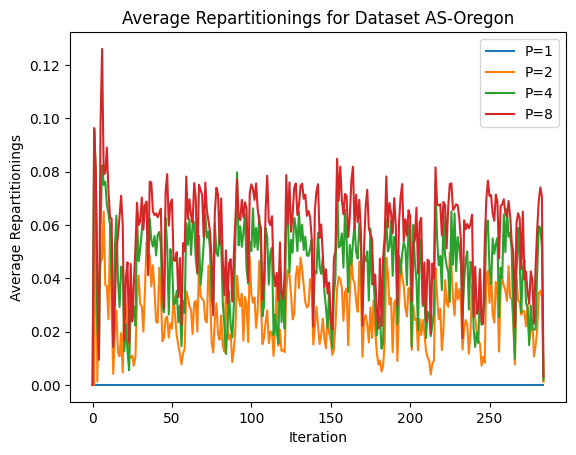

Dataset: AstroPh


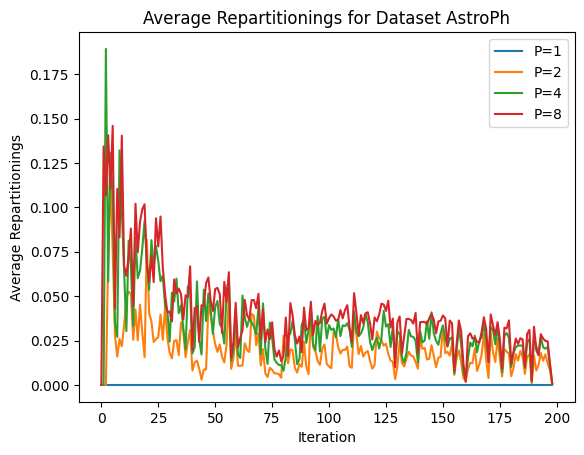

Dataset: Enron


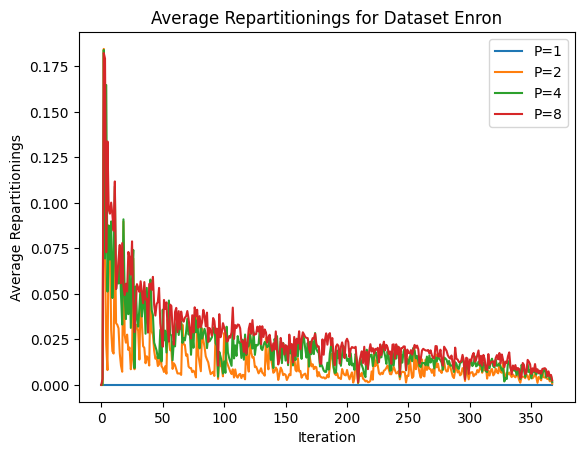

Dataset: DBLP


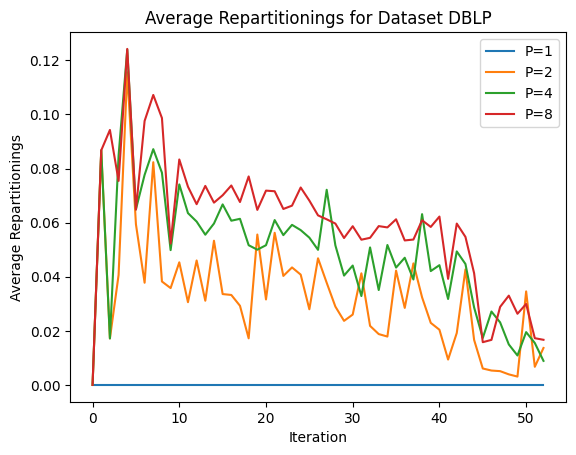

Dataset: CITESEER


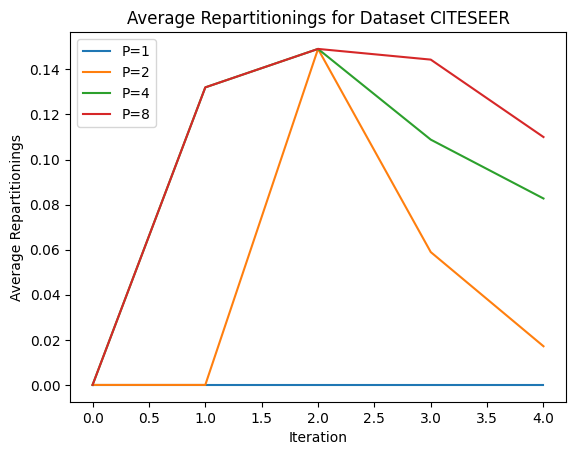

In [148]:
import matplotlib.pyplot as plt
import pandas as pd

for dataset in all_datasets:
    print(f"Dataset: {dataset}")
    data = []
    for partitions in sorted(all_partitions):
        for rf in [1]:
            key = (dataset, partitions, rf)
            if key in everything:
                f1s = everything[key]["average_f1s"]
                # print("f1s: ", f1s)
                # plt.plot(f1s, label=f"P={partitions}")
                partition_sizes = everything[key]["runs"][0]["partition_sizes"] if everything[key]["runs"] else None
                repartitionings = everything[key]["average_repartitionings"] if everything[key]["average_repartitionings"] is not None else None
                repartitioning_percentages = everything[key]["average_repartitioning_percentages"] if everything[key]["average_repartitioning_percentages"] is not None else None
                edge_cuts = everything[key]["average_edge_cuts"] if everything[key]["average_edge_cuts"] is not None else None
                balance = everything[key]["average_balance"] if everything[key]["average_balance"] is not None else None
                plt.plot(repartitioning_percentages, label=f"P={partitions}")
    plt.xlabel("Iteration")
    plt.ylabel("Average Repartitionings")
    plt.title(f"Average Repartitionings for Dataset {dataset}")
    plt.legend()
    plt.show()

In [149]:
import os
import matplotlib.pyplot as plt

plots_dir = os.path.join(cwd, "..", "plots")
os.makedirs(plots_dir, exist_ok=True)

def dataset_slug(name):
    return name.lower().replace(" ", "-")

metrics = [
    ("f1",           "average_f1s",                      "Average F1 Score",           "F1 Score"),
    ("balance",      "average_balance",                   "Average Balance",             "Balance"),
    ("edge-cuts",    "average_edge_cuts",                 "Average Edge Cuts",           "Edge Cut Ratio"),
    ("repartitions", "average_repartitioning_percentages","Average Repartitioning Rate", "Repartitioning Rate"),
]

for dataset in sorted(all_datasets):
    for slug, key_name, title, ylabel in metrics:
        fig, ax = plt.subplots()
        plotted = False
        for partitions in sorted(all_partitions):
            run_key = (dataset, partitions, 1)
            if run_key in everything:
                series = everything[run_key].get(key_name)
                if series is not None:
                    ax.plot(series, label=f"P={partitions}")
                    plotted = True
        if plotted:
            ax.set_xlabel("Iteration")
            ax.set_ylabel(ylabel)
            ax.set_title(f"{title} – {dataset}")
            ax.legend()
            filename = f"{dataset_slug(dataset)}-{slug}.png"
            fig.savefig(os.path.join(plots_dir, filename), bbox_inches="tight", dpi=150)
            print(f"Saved {filename}")
        plt.close(fig)


Saved as-oregon-f1.png
Saved as-oregon-balance.png
Saved as-oregon-edge-cuts.png
Saved as-oregon-repartitions.png
Saved astroph-f1.png
Saved astroph-balance.png
Saved astroph-edge-cuts.png
Saved astroph-repartitions.png
Saved citeseer-f1.png
Saved citeseer-balance.png
Saved citeseer-edge-cuts.png
Saved citeseer-repartitions.png
Saved dblp-f1.png
Saved dblp-balance.png
Saved dblp-edge-cuts.png
Saved dblp-repartitions.png
Saved enron-f1.png
Saved enron-balance.png
Saved enron-edge-cuts.png
Saved enron-repartitions.png


In [150]:
everything = {}
add_to_everything("mu-vary", param_type=float)
print(everything.keys())
# Now, plot balance based on value of mu, for different partition counts and datasets
data = [] 
for dataset in sorted(all_datasets):
    # create plots side by side 
    subplots = []
    plotted = False 
    for partitions in sorted([2,4]):
        subplots.append(plt.subplot(1, 2, len(subplots) + 1))
        print(f"Dataset: {dataset}, Partitions: {partitions}")
        has_plot = False
        for mu in sorted([0, 0.5, 1, 1.5, 2]):  # Assuming these are the mu values used in the runs
            run_key = (dataset, partitions, mu)
            # print(f"Checking run_key: {run_key}")
            if run_key in everything:
                series = everything[run_key].get("average_balance")
                if series is not None:
                    # smooth out series using a rolling mean
                    window_size = len(series) // 10 if len(series) >= 10 else 1
                    series = pd.Series(series).rolling(window=window_size, min_periods=1).mean()
                    subplots[-1].plot(series, label=f"mu={mu}")
                has_plot = True
                plotted = True
                data.append({
                    "Dataset": dataset,
                    "# of partitions": partitions,
                    "mu": mu,
                    "Balance at the last iteration": everything[run_key]["average_balance"][-1] if everything[run_key]["average_balance"] is not None else 0,
                    "Average Balance": np.mean(everything[run_key]["average_balance"]) if everything[run_key]["average_balance"] is not None else 0,
                })
        if has_plot:
            subplots[-1].set_xlabel("Iteration")
            subplots[-1].set_ylabel("Average Balance")
            subplots[-1].set_title(f"P={partitions}")
            subplots[-1].set_ylim(bottom=1, top=3)  # Ensure y-axis starts at 0
            # filename = f"{dataset_slug(dataset)}-balance-P{partitions}.png"
            # fig.savefig(os.path.join(plots_dir, filename), bbox_inches="tight", dpi=150)
            # print(f"Saved {filename}")
    # Add a suptitle for the dataset
    if plotted:
        # add a legend outside the subplots
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize='small', title='mu values', title_fontsize='small', frameon=False, borderaxespad=0.0)
        plt.suptitle(f"Average Balance for Dataset {dataset}")
        plt.savefig(os.path.join(plots_dir, f"{dataset_slug(dataset)}-balance-mu.png"), bbox_inches="tight", dpi=150)
        plt.close()
                


'Searching for profile files in: /Users/stefan/data/Development/VertexVoyage/notebooks/../temporal_runs/mu-vary'

'AS-Oregon: Average F1 score at last iteration: 0.006423651098840674'

'DBLP: Average F1 score at last iteration: 0.0001314314132165211'

'CITESEER: Average F1 score at last iteration: 0.002067493142878765'

'AstroPh: Average F1 score at last iteration: 0.0022648730686539004'

...

'AS-Oregon: Average F1 score at last iteration: 0.006423651098840674'

'AstroPh: Average F1 score at last iteration: 0.0022648730686539004'

'CITESEER: Average F1 score at last iteration: 0.002067493142878765'

'Enron: Average F1 score at last iteration: 0.0006887191453689409'

dict_keys([('AS-Oregon', 4, 1.5), ('DBLP', 4, 1.5), ('CITESEER', 2, 0.5), ('AstroPh', 4, 1.5), ('AS-Oregon', 2, 1.5), ('AstroPh', 4, 2.0), ('AstroPh', 2, 0.0), ('DBLP', 2, 1.0), ('DBLP', 4, 2.0), ('DBLP', 2, 1.5), ('CITESEER', 4, 0.5), ('AstroPh', 2, 1.0), ('DBLP', 2, 0.0), ('AstroPh', 2, 1.5), ('Enron', 2, 1.5), ('Enron', 4, 0.0), ('CITESEER', 4, 1.0), ('Enron', 4, 1.5), ('AS-Oregon', 2, 1.0), ('Enron', 2, 2.0), ('AS-Oregon', 2, 0.0), ('Enron', 4, 1.0), ('CITESEER', 4, 0.0), ('CITESEER', 2, 2.0), ('AS-Oregon', 4, 2.0), ('Enron', 2, 0.5), ('DBLP', 2, 2.0), ('Enron', 4, 0.5), ('DBLP', 4, 0.0), ('AstroPh', 4, 1.0), ('AstroPh', 2, 2.0), ('DBLP', 4, 1.0), ('AstroPh', 4, 0.0), ('AS-Oregon', 4, 0.5), ('DBLP', 4, 0.5), ('AstroPh', 4, 0.5), ('CITESEER', 2, 1.5), ('AS-Oregon', 4, 0.0), ('CITESEER', 2, 0.0), ('Enron', 2, 1.0), ('AS-Oregon', 2, 0.5), ('CITESEER', 4, 2.0), ('AS-Oregon', 2, 2.0), ('CITESEER', 2, 1.0), ('Enron', 2, 0.0), ('DBLP', 2, 0.5), ('AS-Oregon', 4, 1.0), ('AstroPh', 2, 0.5), 

# Sensitivity analysis of the balance penalty parameter ($\mu$) on the balance of the partitions.

In this section, we analyze the effect of the balance penalty parameter ($\mu$) on the balance of the partitions. We will vary $\mu$ and observe how it influences the balance metric across different datasets and partition counts.

The following table shows the average balance at the last iteration for different values of $\mu$ across various datasets and partition counts. The balance metric is calculated as the average deviation of partition sizes from the ideal size, with lower values indicating better balance.

In [151]:
df = pd.DataFrame(data)
for dataset, ds_df in df.groupby("Dataset"):
    print(f"Dataset: {dataset}")
    display(ds_df.pivot(index="mu", columns="# of partitions", values="Balance at the last iteration"))

Dataset: AS-Oregon


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.184991,1.490005
1.0,1.176520,1.195663
1.5,1.103507,1.205658
2.0,1.046417,1.194139


Dataset: AstroPh


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.151076,1.182186
1.0,1.129022,1.119540
1.5,1.077562,1.121671
2.0,1.046346,1.217452


Dataset: CITESEER


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.609681,1.609681
1.0,1.308211,1.626838
1.5,1.168505,1.500000
2.0,1.168505,1.172181


Dataset: DBLP


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.081734,1.162452
1.0,1.034884,1.087492
1.5,1.144728,1.197900
2.0,1.007677,1.143825


Dataset: Enron


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.095280,1.135615
1.0,1.100076,1.103946
1.5,1.015535,1.020822
2.0,1.060122,1.062575


The following table shows the average balance during the iterations for different values of $\mu$ across various datasets and partition counts. 

In [152]:
for dataset, ds_df in df.groupby("Dataset"):
    print(f"Dataset: {dataset}")
    display(ds_df.pivot(index="mu", columns="# of partitions", values="Average Balance"))

Dataset: AS-Oregon


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.143465,1.511846
1.0,1.121648,1.232893
1.5,1.104612,1.177464
2.0,1.097356,1.153163


Dataset: AstroPh


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.235791,1.512762
1.0,1.144547,1.273727
1.5,1.114537,1.213827
2.0,1.102533,1.201570


Dataset: CITESEER


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.921936,2.121936
1.0,1.524653,1.839536
1.5,1.340769,1.662446
2.0,1.340769,1.545901


Dataset: DBLP


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.302229,1.595834
1.0,1.173825,1.403570
1.5,1.148723,1.334701
2.0,1.123562,1.249495


Dataset: Enron


# of partitions,2,4
mu,,
0.0,2.000000,2.500000
0.5,1.140002,1.265857
1.0,1.105194,1.188826
1.5,1.088201,1.166369
2.0,1.082168,1.145919
